<table width="100%" style="border: none; border-collapse: collapse; margin: 0; padding: 0;">
<tr style="border: none; background: none;">
<td width="50%" style="border: none; border-bottom: 2px solid #555555; vertical-align: top; padding-bottom: 10px; text-align: left;">
<h2 style="margin: 0; padding: 0; line-height: 1;"><span style="color: #B30033;">▍</span> Práctica 3:</h2>
<h1 style="margin: 5px 0 0 0; font-size: 200%; line-height: 1.2;">Aprendizaje de modelos basados en redes neuronales</h1>
</td>
<td width="50%" style="border: none; border-bottom: 2px solid #555555; vertical-align: bottom; padding-bottom: 10px; text-align: right;">
<div style="display: inline-block; border-left: 2px solid #555555; padding-left: 15px; text-align: right;">
<p style="margin: 0 0 10px 0; font-size: 140%; font-weight: bold;">Minería de Datos, 2025-26</p>
<p style="margin: 0; font-size: 100%; color: #666666;">José Antonio Gámez Martín<a href="mailto:Jose.Gamez@uclm.es" style="color: #888888; text-decoration: none; margin-left: 10px; font-size: 80%;">✉ Jose.Gamez@uclm.es</a></p>
<p style="margin: 5px 0 0 0; font-size: 100%; color: #666666;">Pablo Torrijos Arenas<a href="mailto:Pablo.Torrijos@uclm.es" style="color: #888888; text-decoration: none; margin-left: 10px; font-size: 80%;">✉ Pablo.Torrijos@uclm.es</a></p>
</div>
</td>
</tr>
</table>
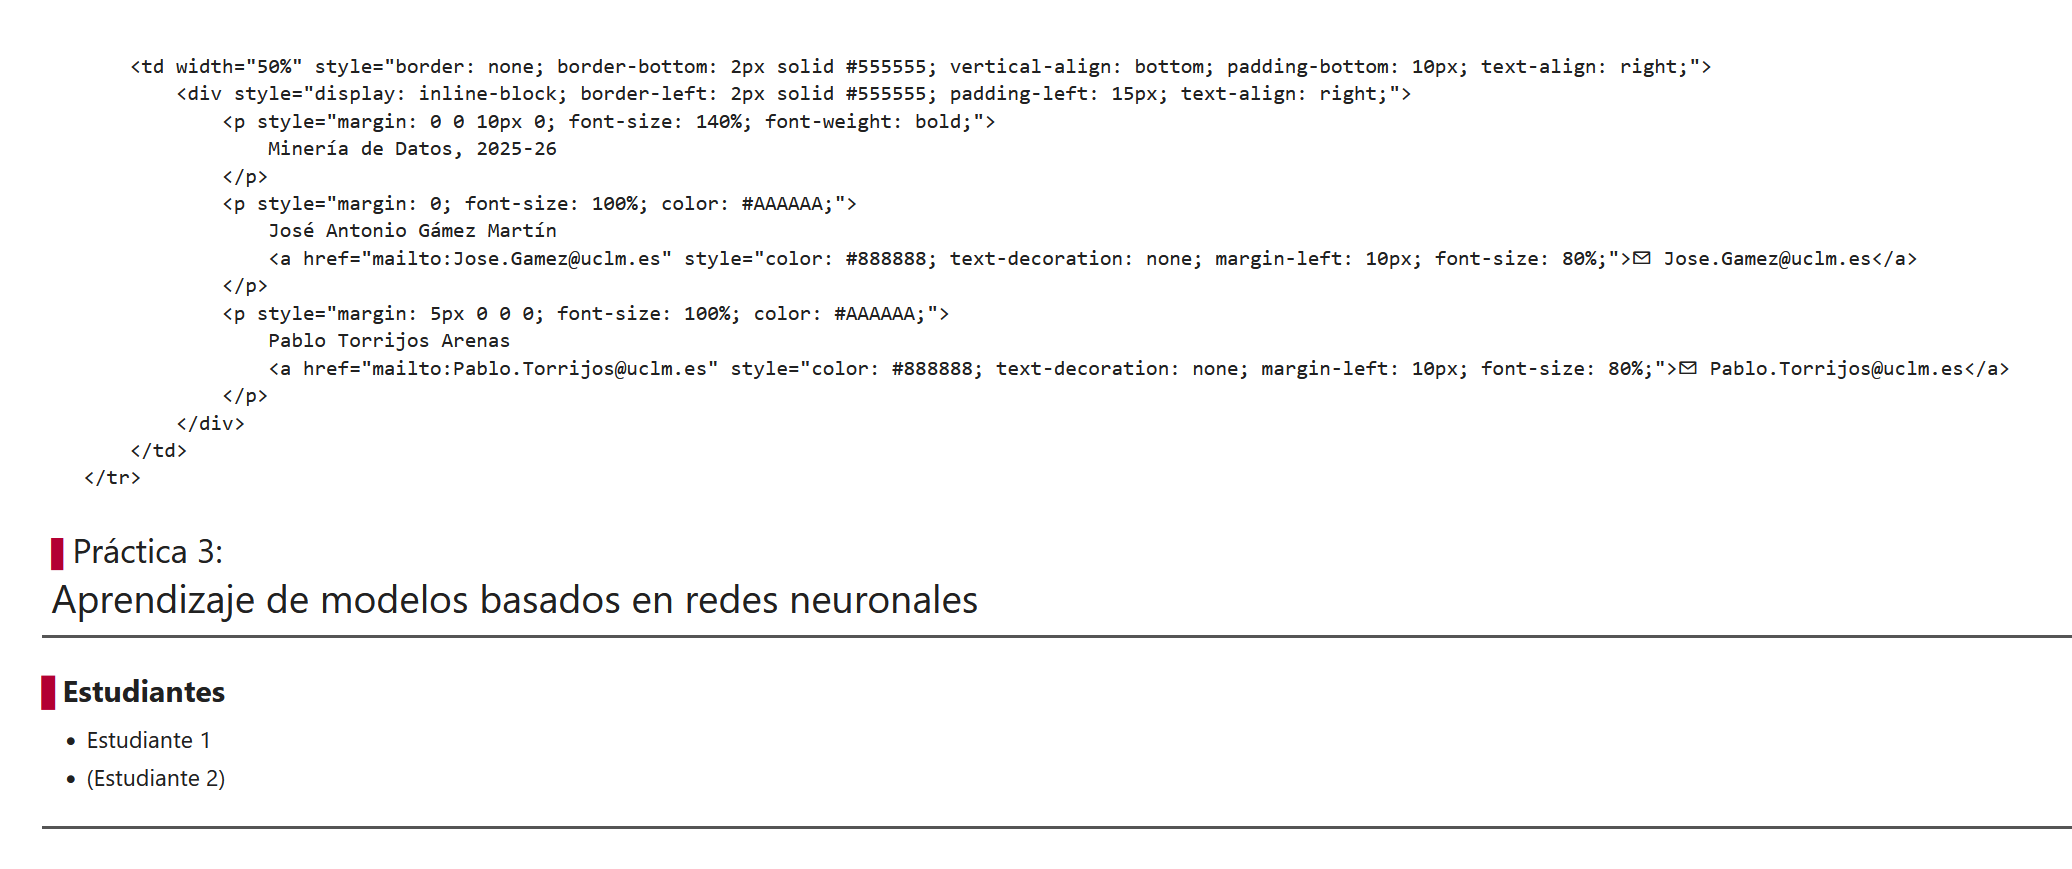

<h3 style="margin: 0 0 10px 0; font-weight: bold;">
<span style="color: #B30033; font-size: 120%; margin-right: 5px;">▍</span>Estudiantes</h3>

* Diego García Díaz
* Alberto Pérez Álvarez

## 1. Introducción

En esta práctica aplicaremos **Deep Learning** para clasificar imágenes satelitales del conjunto de datos **EuroSAT**. El objetivo es identificar el uso del suelo (bosques, zonas industriales, cultivos, etc.) utilizando tanto redes diseñadas desde cero como técnicas de Transfer Learning.

### Instrucciones de Dataset (Kaggle)
Para que esta libreta funcione, debes añadir el siguiente dataset a tu entorno (en principio, si clonais la libreta lo deberíais de tener por defecto):
1.  En el menú derecho, pulsa **Add Input**.
2.  Busca **"EuroSAT Dataset"** (del usuario *Gota Dahiya*).
3.  Añádelo pulsando el botón `+`.

### Configuración Inicial
Asegúrate de tener activada la **GPU** (T4 x2 o P100) para acelerar el entrenamiento.

In [1]:
#!pip install "protobuf==3.20.3" > /dev/null 2>&1  #Si no, da un error de compatibilidad entre liberías.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pathlib
import PIL.Image
import time
from sklearn.metrics import classification_report, confusion_matrix

/Users/diego/dev/Analisis-de-Datos-y-Modelos-de-Prediccion-de-Abandono-Academico/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Reproducibilidad
SEED = 2025
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.16.2
GPU Available: True


---

## 2. Carga y Gestión de Datos

Utilizaremos `tf.keras.utils.image_dataset_from_directory`. Esta función crea un generador de datos que carga las imágenes del disco bajo demanda, evitando saturar la memoria RAM.

In [3]:
#data_dir = pathlib.Path('/kaggle/input/eurosat-dataset/EuroSAT')

# Ruta estándar basada en el dataset eurosat-dataset. Contiene las imágenes .jpg, mientras que 'EuroSATallBands' contiene archivos .tif
KAGGLE_PATH = '/kaggle/input/eurosat-dataset/EuroSAT'
# Ruta que tendria en local.
LOCAL_PATH = './EuroSAT' 

# Kaggle siempre define la variable de entorno 'KAGGLE_KERNEL_RUN_TYPE'
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None:
    print("Entorno de Kaggle")
    data_dir = KAGGLE_PATH
else:
    data_dir = LOCAL_PATH
    print("Entorno Local:",data_dir)
    
data_dir = pathlib.Path(data_dir)

# Verificación del contenido
all_images = list(data_dir.glob('*/*.jpg'))
image_count = len(all_images)
print(f"Total de imágenes encontradas: {image_count}")

# Verificación de dimensiones reales
first_image = PIL.Image.open(all_images[0])
print(f"Dimensiones reales de una imagen de muestra: {first_image.size}")
print(f"Formato de imagen: {first_image.format}")

# Parámetros Globales
# Ajustamos las constantes al tamaño real detectado (debería ser 64x64)
BATCH_SIZE = 64
IMG_HEIGHT = 64
IMG_WIDTH = 64

Entorno Local: ./EuroSAT
Total de imágenes encontradas: 27000
Dimensiones reales de una imagen de muestra: (64, 64)
Formato de imagen: JPEG


### 2.1 Creación de Pipelines (`tf.data`) y División Train/Val/Test

Para garantizar la robustez de los resultados, dividiremos los datos de la siguiente manera:
* **70% Entrenamiento:** Para ajustar los pesos de los modelos.
* **15% Validación:** Para ajustar hiperparámetros y *Early Stopping*.
* **15% Test:** Conjunto para la evaluación final.

In [4]:
# Cargamos el dataset completo sin dividir inicialmente
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_mode='int'
)

class_names = full_ds.class_names
print(f"Clases encontradas: {class_names}")

# Calculamos el número de batches
n_batches = tf.data.experimental.cardinality(full_ds).numpy()

train_size = int(0.7 * n_batches)
val_size = int(0.15 * n_batches)
test_size = n_batches - train_size - val_size

print(f"Batches -> Train: {train_size}, Val: {val_size}, Test: {test_size}")

# Realizar la división usando take() y skip()
train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

Found 27000 files belonging to 11 classes.


I0000 00:00:1764574708.333053  351440 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1459 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'allBands']
Batches -> Train: 295, Val: 63, Test: 64


### 2.2 Optimización (Performance)
Usamos `.cache()` y `.prefetch()` para que la GPU no tenga que esperar a la carga de datos.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 2.3 Análisis Exploratorio (EDA)
En esta práctica no nos vamos a centar en el EDA y preprocesamiento. Solo se piden (obligatoriamente) las siguientes tareas:

**Tarea:**
1.  Visualiza una cuadrícula de imágenes del conjunto de entrenamiento con sus etiquetas (preferiblemente mostrando alguna de cada clase).
2.  Analiza si el dataset está balanceado mostrando un gráfico de barras con la cantidad de imágenes por clase.

2025-12-01 08:38:35.321358: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


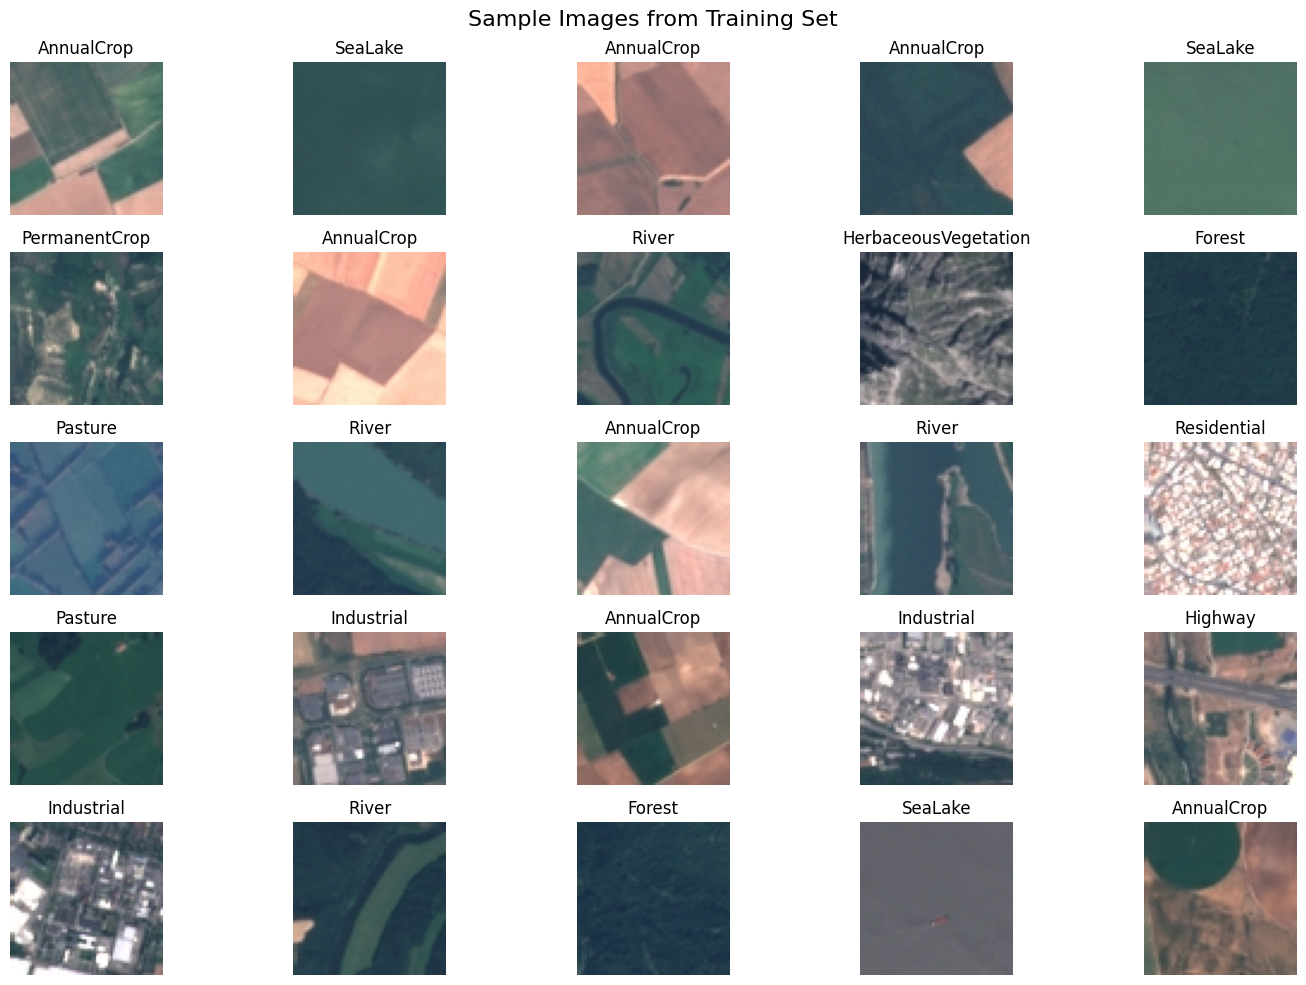

Calculating class distribution... (this may take a moment)


2025-12-01 08:38:42.214091: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


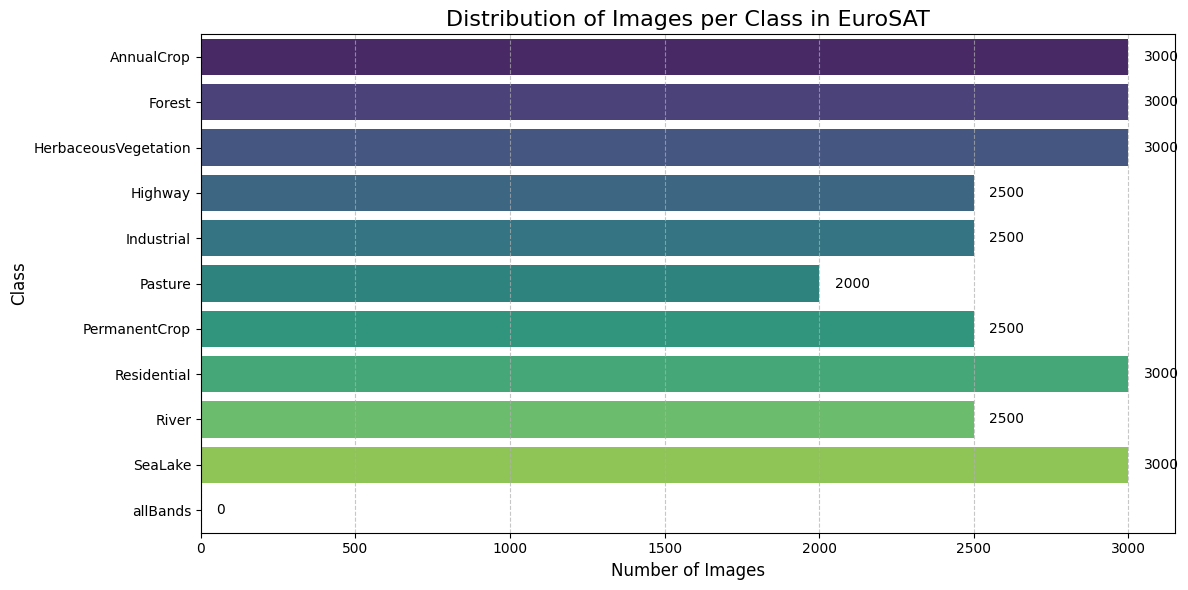

Mean images per class: 2454.55
Standard deviation: 879.05
Conclusion: There are imbalances in the dataset.


In [6]:
#TODO: LO HA HECHO GEMINI, REVISAR Y QUITAR ENUMERACIONES Y PASAR COMENTARIOS (Y GRÁFICAS) A ESPAÑOL Y ESO

# --- 1. Visualize a grid of images ---
plt.figure(figsize=(15, 10))

# We extract the first batch from the training dataset
for images, labels in train_ds.take(1):
    # We display the first 25 images of the batch
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        # Images in TensorFlow are tensors, we convert them to numpy and to uint8 [0-255]
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # We get the name of the class using the index of the label
        label_index = int(labels[i])
        plt.title(class_names[label_index])
        plt.axis("off")

plt.suptitle("Sample Images from Training Set", fontsize=16)
plt.tight_layout()
plt.show()

# --- 2. Class Balance Analysis ---
print("Calculating class distribution... (this may take a moment)")

# Initialize a dictionary to count classes
class_counts = {name: 0 for name in class_names}

# We iterate over the entire dataset (full_ds) to count correctly.
# Note: Iterating over a tf.data.Dataset can be slow depending on the hardware,
# but it is the correct way to do it with image_dataset_from_directory without loading everything into RAM.
for _, labels in full_ds:
    for label in labels:
        class_name = class_names[int(label)]
        class_counts[class_name] += 1

# Convert to DataFrame for easier plotting
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Class', data=df_counts, palette='viridis', hue='Class', legend=False)
plt.title('Distribution of Images per Class in EuroSAT', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the number at the end of each bar
for index, value in enumerate(df_counts['Count']):
    plt.text(value + 50, index, str(value), va='center')

plt.tight_layout()
plt.show()

# Calculate statistics
mean_count = df_counts['Count'].mean()
std_count = df_counts['Count'].std()
print(f"Mean images per class: {mean_count:.2f}")
print(f"Standard deviation: {std_count:.2f}")

if std_count < (mean_count * 0.1): # Arbitrary threshold of 10%
    print("Conclusion: The dataset is remarkably balanced.")
else:
    print("Conclusion: There are imbalances in the dataset.")

---
## 3. Baseline: Perceptrón Multicapa (MLP)

Antes de usar redes convolucionales, diseñaremos una red densa clásica (`Sequential`) como baseline para comprobar las limitaciones de tratar imágenes como datos tabulares planos.

**Requisitos:**
1.  La red debe comenzar normalizando los valores de entrada ($0-1$) y aplanando la imagen para convertir la matriz 3D en un vector 1D.
2.  Eres libre de elegir la profundidad y anchura de la red. Ten en cuenta que la entrada tiene más de $12.000$ dimensiones ($64 \times 64 \times 3$).
3.  Configura correctamente la última capa para un problema de clasificación de 10 clases.
4.  Compila el modelo utilizando el optimizador `adam` y la función de pérdida `sparse_categorical_crossentropy`.
5.  Se recomienda guardar el **tiempo de entrenamiento**, en este y todos los modelos, para posibles comparaciones posteriores.
6.  Guarda el mejor modelo generado como `best_mlp.keras`.

**Evaluación:**
1.  Utiliza `accuracy` como métrica de monitorización. Pensad por qué podemos usar esta métrica.
2.  Genera y analiza las gráficas de `loss` y `accuracy` (Entrenamiento vs. Validación).
3.  **Pregunta:** ¿Por qué, teóricamente, un MLP no es la arquitectura ideal para este problema comparado con una CNN?

Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,457,482 (24.63 MB)

 Trainable params: 6,457,482 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

...

285/295 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2157 - loss: 2.6158

2025-12-01 08:38:52.937434: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25165824 exceeds 10% of free system memory.



Epoch 1: val_accuracy improved from None to 0.34177, saving model to best_mlp.keras


2025-12-01 08:38:53.228138: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25165824 exceeds 10% of free system memory.
2025-12-01 08:38:53.264873: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25165824 exceeds 10% of free system memory.
2025-12-01 08:38:53.303792: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25165824 exceeds 10% of free system memory.


295/295 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.2870 - loss: 2.0238 - val_accuracy: 0.3418 - val_loss: 1.7512
Epoch 2/50
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3781 - loss: 1.6521
Epoch 2: val_accuracy improved from 0.34177 to 0.42188, saving model to best_mlp.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3943 - loss: 1.6093 - val_accuracy: 0.4219 - val_loss: 1.5353
Epoch 3/50
278/295 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4201 - loss: 1.5496
Epoch 3: val_accuracy improved from 0.42188 to 0.44965, saving model to best_mlp.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4240 - loss: 1.5419 - val_accuracy: 0.4497 - val_loss: 1.5191
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4464 - loss: 1.4819
Epoch 4: val_accuracy did not improve from 0.44965
295/295 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4495 - loss: 1.4795 - val_accuracy: 0.4459 - val_loss: 1.5208
Epoch 5/50
285/295 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

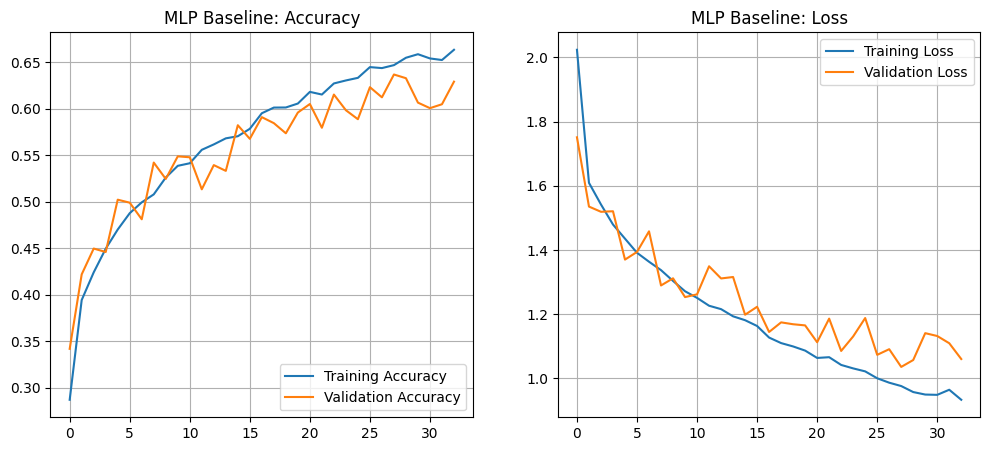

In [7]:
# TODO: HECHO CON GEMINI, repasar para ver si esta bien y eso

# 1. Architecture Design
def build_mlp_model():
    model = models.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        
        # Normalization (0-255 -> 0-1)
        layers.Rescaling(1./255),
        
        # Flattening (3D -> 1D vector)
        # 64 * 64 * 3 = 12,288 dimensions
        layers.Flatten(),
        
        # Hidden Layers (Dense)
        # We start wide because the input is large
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        
        # Output Layer (10 classes)
        # Softmax returns probabilities for each class
        layers.Dense(10, activation='softmax')
    ], name="MLP_Baseline")
    
    return model

mlp_model = build_mlp_model()
mlp_model.summary()

# 2. Compilation
mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Callbacks
callbacks_list_mlp = [
    callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_mlp.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 4. Training
print("\nStarting MLP training...")
start_time = time.time()

history_mlp = mlp_model.fit(
    train_ds,
    epochs=50, # Set a high max, EarlyStopping will stop it
    validation_data=val_ds,
    callbacks=callbacks_list_mlp
)

end_time = time.time()
mlp_training_time = end_time - start_time
print(f"\nTotal Training Time (MLP): {mlp_training_time:.2f} seconds")

# --- Evaluation & Plotting ---

def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name}: Accuracy')
    plt.grid(True)
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name}: Loss')
    plt.grid(True)
    
    plt.show()

plot_history(history_mlp, "MLP Baseline")

TODO: Gemini

Why, theoretically, is an MLP not the ideal architecture for this problem compared to a CNN?

Loss of Spatial Structure: An image contains critical information in the arrangement of pixels (e.g., lines, textures, shapes formed by neighboring pixels). By using Flatten(), the MLP destroys this 2D/3D structure, treating pixels that were neighbors just like pixels that were far apart. It loses the concept of "locality".Parameter Explosion: In an MLP, every input unit is connected to every output unit of the next layer. With an input of $64 \times 64 \times 3 = 12,288$ features, a single dense layer with 512 neurons would require over 6 million parameters just for that layer ($12,288 \times 512 + 512$). This makes the model huge, computationally expensive, and very prone to overfitting on small datasets.Lack of Translation Invariance: If a feature (e.g., a tree) appears in the top-left corner of an image during training, an MLP learns weights specific to those pixel positions. If the tree appears in the bottom-right in a test image, the MLP won't recognize it unless it has seen trees there before. CNNs use shared weights (filters) that slide across the image, allowing them to detect the same feature anywhere.

---
## 4. Arquitectura Propia: Red Neuronal Convolucional (CNN)

Ahora diseñarás una arquitectura adaptada específicamente para el procesamiento de imágenes. Tu objetivo es **superar el rendimiento del Baseline (MLP)** aprovechando la capacidad de las CNN para aprender patrones espaciales y texturas.

Eres libre de definir la profundidad de la red y el número de filtros, pero debes cumplir los siguientes **requisitos**:
1.  **Data Augmentation:** Incluye capas de preprocesamiento al inicio (ej. `RandomFlip`, `RandomRotation`) para mejorar la generalización.
2.  **Estructura:** Se recomienda usar bloques repetitivos de `Conv2D` $\rightarrow$ `MaxPooling2D`.
    * *Advertencia:* Las imágenes son de $64 \times 64$. Si abusas de las capas de *pooling*, reducirás la imagen a $1 \times 1$ antes de tiempo, perdiendo información.
3.  **Regularización:** Es obligatorio implementar `Dropout` y/o `BatchNormalization` para reducir el sobreajuste. Experimenta con su posición y valores.
4.  **Callbacks:** Configura `EarlyStopping` y `ModelCheckpoint`.

**Tarea:**
1.  Diseña, compila y entrena tu modelo.
2.  Compara las curvas de aprendizaje con las del MLP. ¿Converge más rápido? ¿Sufre menos sobreajuste?
3.  Guarda el mejor modelo generado como `best_cnn.keras`.
4.  Compara el ratio entre tamaño del modelo y accuracy del modelo generado (CNN) con el MLP anterior.
5.  Se valorará el estudio de la influencia del aumento de datos y del uso de `Dropout` y/o `BatchNormalization`.

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,493,130 (9.51 MB)

 Trainable params: 2,492,170 (9.51 MB)

 Non-trainable params: 960 (3.75 KB)


Iniciando entrenamiento de la CNN...
Epoch 1/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.6041 - loss: 1.2840 - val_accuracy: 0.1195 - val_loss: 16.4725
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6921 - loss: 0.8794 - val_accuracy: 0.6729 - val_loss: 1.0032
Epoch 3/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7281 - loss: 0.7821 - val_accuracy: 0.6706 - val_loss: 1.0708
Epoch 4/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7537 - loss: 0.7149 - val_accuracy: 0.6545 - val_loss: 1.1905
Epoch 5/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7807 - loss: 0.6374 - val_accuracy: 0.6992 - val_loss: 1.0628
Epoch 6/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8150 - loss: 0.5554 - val_accuracy: 0.8061 - val_loss: 0.5979
Epoch 7/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8338 - loss: 0.4984 - val_accuracy: 0.6885 - val_loss: 1.1985
Epoch 8/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - ac

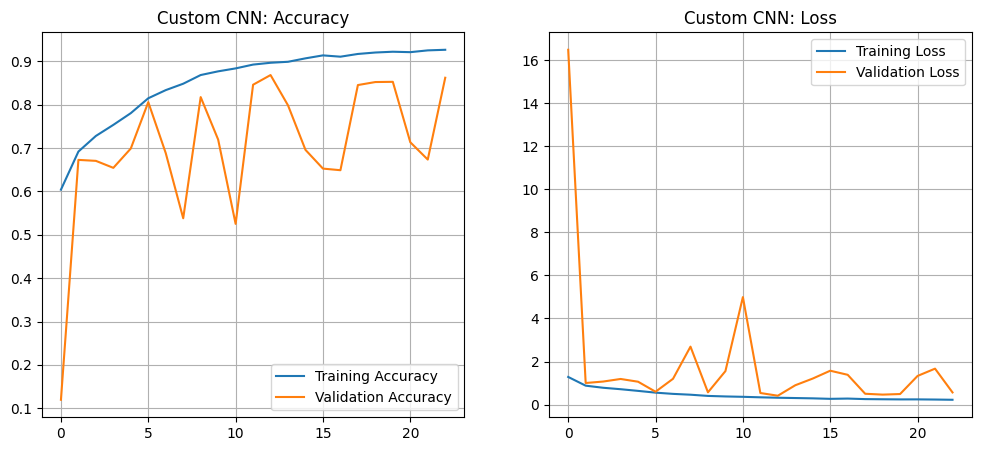


      COMPARATIVA MLP vs CNN
Métrica              | MLP (Baseline)  | CNN (Propia)   
--------------------------------------------------------
Parámetros           | 6,457,482       | 2,493,130      
Val Accuracy         | 0.6369          | 0.8686
--------------------------------------------------------
Eficiencia           | 10,138,850      | 2,870,445      
(Params por 1% Acc)  | (Menor es mejor)  |


In [8]:
# TODO: HECHO CON GEMINI, REVISAR Y "HUMANIZAR xd"

# Definición de función para visualizar el historial (por si no está en memoria)
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name}: Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name}: Loss')
    plt.grid(True)
    plt.show()

# --- 4. Arquitectura Propia: CNN ---

def build_cnn_model():
    # Definimos explícitamente el input shape para evitar ambigüedades
    inputs = keras.Input(shape=(64, 64, 3))

    # 1. Data Augmentation
    # Estas capas solo se activan durante el entrenamiento (training=True)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    # 2. Normalización (Rescaling 0-1)
    x = layers.Rescaling(1./255)(x)

    # 3. Extracción de Características (Bloques Convolucionales)
    # Bloque 1: Filtros de bajo nivel (bordes, colores)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x) # Regularización: normaliza las activaciones
    x = layers.MaxPooling2D((2, 2))(x) # Reduce dim espacial a 32x32

    # Bloque 2: Filtros de nivel medio (texturas, formas simples)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce dim espacial a 16x16

    # Bloque 3: Filtros de alto nivel (objetos complejos)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce dim espacial a 8x8

    # Bloque 4: Mayor profundidad
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Reduce dim espacial a 4x4

    # 4. Clasificación
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x) # Regularización: apaga neuronas aleatoriamente
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Custom_CNN")
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

# Compilación
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_list_cnn = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10, # Mayor paciencia que en MLP
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0 # Reducimos verbosidad para limpiar la salida
    )
]

# Entrenamiento
print("\nIniciando entrenamiento de la CNN...")
start_time_cnn = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks_list_cnn,
    verbose=1
)

end_time_cnn = time.time()
cnn_training_time = end_time_cnn - start_time_cnn
print(f"\nTiempo total de entrenamiento (CNN): {cnn_training_time:.2f} segundos")

# Visualización
plot_history(history_cnn, "Custom CNN")

# --- Comparativa de Eficiencia (Tarea 4) ---
# Intentamos recuperar los valores del MLP anterior. Si no existen, usamos marcadores.
try:
    mlp_val_acc = max(history_mlp.history['val_accuracy'])
    mlp_params = mlp_model.count_params()
except NameError:
    mlp_val_acc = 0.0 # No encontrado
    mlp_params = 0    # No encontrado

cnn_val_acc = max(history_cnn.history['val_accuracy'])
cnn_params = cnn_model.count_params()

print("\n" + "="*40)
print("      COMPARATIVA MLP vs CNN")
print("="*40)
print(f"{'Métrica':<20} | {'MLP (Baseline)':<15} | {'CNN (Propia)':<15}")
print("-" * 56)
print(f"{'Parámetros':<20} | {mlp_params:<15,} | {cnn_params:<15,}")
print(f"{'Val Accuracy':<20} | {mlp_val_acc:.4f}          | {cnn_val_acc:.4f}")

if cnn_params > 0 and mlp_params > 0:
    ratio_mlp = mlp_params / mlp_val_acc
    ratio_cnn = cnn_params / cnn_val_acc
    print("-" * 56)
    print(f"{'Eficiencia':<20} | {int(ratio_mlp):<15,} | {int(ratio_cnn):<15,}")
    print(f"(Params por 1% Acc)  | (Menor es mejor)  |")

---
## 5. Transfer Learning (Estado del Arte)

En esta sección, utilizaremos una red preentrenada en ImageNet para aprovechar el conocimiento extraído de millones de imágenes. Dado el tamaño de entrada ($64 \times 64$), buscamos arquitecturas eficientes que no reduzcan excesivamente la dimensionalidad espacial.

Debes construir un nuevo modelo siguiendo estas **pautas**:
1.  Integra la misma capa de aumento de datos definida en la sección anterior.
2.  Importa una arquitectura robusta (como `ResNet50V2` o `EfficientNetV2B0`) con pesos de `imagenet`. Recuerda configurar `include_top=False` y definir el `input_shape` correcto.
3.  Congela los pesos del modelo base (Feature Extraction) y añade tu(s) propia(s) capa(s) completamente contectada(s) para clasificación. Se recomienda usar `GlobalAveragePooling2D` para conectar la base convolucional con la capa de salida.

**Tarea:**
1.  Construye, compila y entrena el modelo.
2.  Guarda el mejor modelo generado como `best_transfer.keras`.
3.  Analiza si el uso de modelos preentrenados justifica la mejora en precisión respecto a tu CNN "artesanal", considerando el tiempo de entrenamiento y el número de parámetros.
4.  Se valorará el estudio de descongelar los últimos bloques del modelo base para realizar un *Fine-Tuning* con una tasa de aprendizaje reducida (ej. $1e-5$).

Model: "Transfer_EfficientNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 2, 2, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)


--- Fase 1: Feature Extraction (Base Congelada) ---
Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.7354 - loss: 0.8863 - val_accuracy: 0.8549 - val_loss: 0.4828
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8393 - loss: 0.4998 - val_accuracy: 0.8817 - val_loss: 0.3686
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8586 - loss: 0.4334 - val_accuracy: 0.8906 - val_loss: 0.3335
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8651 - loss: 0.4044 - val_accuracy: 0.8993 - val_loss: 0.3087
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8730 - loss: 0.3820 - val_accuracy: 0.9053 - val_loss: 0.2941
Epoch 6/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8770 - loss: 0.3692 - val_accuracy: 0.9117 - val_loss: 0.2791
Epoch 7/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8798 - loss: 0.3513 - val_accuracy: 0.9102 - val_loss: 0.2734
Epoch 8/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 

E0000 00:00:1764575096.997557  351440 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Transfer_EfficientNetV2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


295/295 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.4024 - loss: 2.5600 - val_accuracy: 0.4784 - val_loss: 1.8792
Restoring model weights from the end of the best epoch: 20.

Tiempo total (Extraction + FineTuning): 169.26 segundos


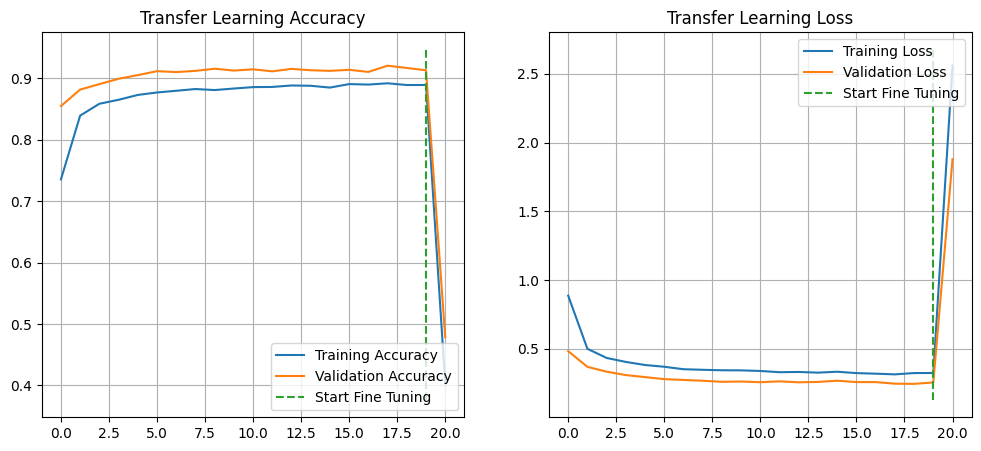


      COMPARATIVA DE ARQUITECTURAS
Modelo               | Parámetros   | Val Acc    | Tiempo(s) 
------------------------------------------------------------
MLP Baseline         | 6,457,482    | 0.6369     | 56.2
CNN Propia           | 2,493,130    | 0.8686     | 175.0
Transfer Learning    | 5,932,122    | 0.9206     | 169.3
------------------------------------------------------------


In [9]:
# TODO: GEMINI, HUMANIZAR

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetV2B0
import time
import matplotlib.pyplot as plt

# Definición de función plot_history (por si acaso no está en memoria)
def plot_history(history, title="Model History"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# --- 5. Transfer Learning con EfficientNetV2B0 ---

def build_transfer_model():
    # Input
    inputs = keras.Input(shape=(64, 64, 3))
    
    # 1. Data Augmentation (Misma que en la CNN)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # Nota: EfficientNetV2B0 incluye su propia capa de preprocesamiento/normalización interna.
    # No es necesario añadir Rescaling(1./255) aquí si pasamos valores [0-255].
    
    # 2. Modelo Base (Preentrenado en ImageNet)
    base_model = EfficientNetV2B0(
        include_top=False, # Quitamos la cabeza de clasificación (1000 clases)
        weights='imagenet',
        input_shape=(64, 64, 3)
    )
    
    # 3. Congelar pesos (Feature Extraction)
    base_model.trainable = False
    
    # Pasar los inputs por el modelo base
    # training=False es importante para mantener la BatchNormalization en modo inferencia
    x = base_model(x, training=False)
    
    # 4. Cabezal de Clasificación Propio
    x = layers.GlobalAveragePooling2D()(x) # Reduce (Batch, 2, 2, 1280) -> (Batch, 1280)
    x = layers.Dropout(0.2)(x) # Regularización extra
    outputs = layers.Dense(10, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name="Transfer_EfficientNetV2")
    return model, base_model

transfer_model, base_model = build_transfer_model()
transfer_model.summary()

# --- FASE 1: Feature Extraction (Entrenamiento del clasificador) ---

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_transfer = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_transfer.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\n--- Fase 1: Feature Extraction (Base Congelada) ---")
start_time_tl = time.time()

history_tl = transfer_model.fit(
    train_ds,
    epochs=20, # Suele converger rápido
    validation_data=val_ds,
    callbacks=callbacks_transfer
)

# --- FASE 2: Fine-Tuning (Ajuste Fino) ---

# Descongelamos el modelo base
base_model.trainable = True

# Opcional: Congelar las primeras capas para no destruir características básicas
# EfficientNetV2B0 tiene muchos layers. Vamos a descongelar solo los últimos bloques.
# Por simplicidad, aquí descongelamos todo pero usamos un Learning Rate muy bajo.
print(f"\nNúmero de capas en el modelo base: {len(base_model.layers)}")

# Re-compilamos con una tasa de aprendizaje muy baja (Low Learning Rate)
# Esto es CRUCIAL para no "romper" los pesos preentrenados
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5), # 10x o 100x más pequeño que el default
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Guardamos si mejora el anterior best_transfer.keras
    callbacks.ModelCheckpoint('best_transfer.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\n--- Fase 2: Fine-Tuning (Ajuste Fino con LR bajo) ---")
# Entrenamos unas pocas épocas más
history_finetune = transfer_model.fit(
    train_ds,
    epochs=20, 
    initial_epoch=history_tl.epoch[-1], # Continuar donde lo dejamos
    validation_data=val_ds,
    callbacks=callbacks_finetune
)

end_time_tl = time.time()
tl_training_time = end_time_tl - start_time_tl
print(f"\nTiempo total (Extraction + FineTuning): {tl_training_time:.2f} segundos")

# Unir historiales para visualizar
acc = history_tl.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_tl.history['loss'] + history_finetune.history['loss']
val_loss = history_tl.history['val_loss'] + history_finetune.history['val_loss']

# Graficar
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([len(history_tl.history['accuracy'])-1,len(history_tl.history['accuracy'])-1], 
         plt.ylim(), label='Start Fine Tuning', ls='--') # Línea vertical
plt.legend(loc='lower right')
plt.title('Transfer Learning Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([len(history_tl.history['loss'])-1,len(history_tl.history['loss'])-1], 
         plt.ylim(), label='Start Fine Tuning', ls='--')
plt.legend(loc='upper right')
plt.title('Transfer Learning Loss')
plt.grid(True)
plt.show()

# --- Comparativa Final (Tarea 3 y 4) ---
# Intentamos recuperar métricas anteriores
try:
    # Usamos try/except por si no se ejecutaron las celdas previas en esta sesión
    mlp_acc = max(history_mlp.history['val_accuracy'])
    cnn_acc = max(history_cnn.history['val_accuracy'])
    mlp_par = mlp_model.count_params()
    cnn_par = cnn_model.count_params()
except NameError:
    mlp_acc, cnn_acc, mlp_par, cnn_par = 0, 0, 0, 0

tl_acc = max(val_acc)
tl_par = transfer_model.count_params()

print("\n" + "="*60)
print("      COMPARATIVA DE ARQUITECTURAS")
print("="*60)
print(f"{'Modelo':<20} | {'Parámetros':<12} | {'Val Acc':<10} | {'Tiempo(s)':<10}")
print("-" * 60)
print(f"{'MLP Baseline':<20} | {mlp_par:<12,} | {mlp_acc:.4f}     | {mlp_training_time if 'mlp_training_time' in locals() else 0:.1f}")
print(f"{'CNN Propia':<20} | {cnn_par:<12,} | {cnn_acc:.4f}     | {cnn_training_time if 'cnn_training_time' in locals() else 0:.1f}")
print(f"{'Transfer Learning':<20} | {tl_par:<12,} | {tl_acc:.4f}     | {tl_training_time:.1f}")
print("-" * 60) 

---
## 6. (Opcional) Nuevas Fronteras: Vision Transformers (ViT)

Mientras que las CNN han dominado la visión por computador durante una década, los **Transformers** (originalmente diseñados para texto) han irrumpido con fuerza en el campo.

A diferencia de una CNN, que mira píxeles vecinos, un **Vision Transformer (ViT)** divide la imagen en "parches" (por ejemplo, cuadrados de $16 \times 16$) y procesa la relación de cada parche con todos los demás simultáneamente mediante mecanismos de **Atención**.

**Desafío Técnico:**
Los ViT son modelos muy pesados y requieren una resolución de entrada específica (generalmente $224 \times 224$). Además, su integración en Keras requiere adaptadores especiales.

**Tarea (Bonus):**
1.  Instala la librería `transformers` de Hugging Face.
2.  Utiliza la clase `ViTWrapper` proporcionada abajo para cargar un modelo base de Google (`vit-base-patch16-224`).
3.  **Completa la función `build_vit_classifier`**:
    * Añade tu capa de **Data Augmentation** al inicio.
    * Observa cómo adaptamos la imagen (`Resizing`, `Rescaling` y `Permute`) para que sea compatible con el modelo de Google.
    * Añade tu(s) propia(s) capa(s) completamente contectada(s) de clasificación al final (Capas Densas y de Salida).
4.  Entrena por pocas épocas y compara los resultados (y el tiempo de ejecución) con tu mejor CNN.

In [10]:
# NECESARIO: pip install transformers
#!pip install transformers
''' Codigo original
from transformers import TFViTModel
from tensorflow.keras import layers, models

# --- CLASE DE UTILIDAD PROPORCIONADA ---
# Esta capa envuelve el modelo de Hugging Face para evitar errores de compatibilidad con Keras 3
class ViTWrapper(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Cargamos el modelo base pre-entrenado
        self.vit = TFViTModel.from_pretrained('google/vit-base-patch16-224')
        self.vit.trainable = False # Congelamos pesos base
        
    def call(self, inputs):
        # El modelo espera 'pixel_values'
        # Retornamos 'pooler_output' que es la representación vectorial de la imagen
        return self.vit(pixel_values=inputs).pooler_output

# --- CLASIFICADOR INCOMPLETO ---
def build_vit_classifier():
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # 1. Data Augmentation
    # TODO: Añade aquí tu capa de aumento de datos
    
    # 2. Adaptación de Dimensionalidad (Necesario para ViT)
    # Redimensionamos a 224x224 (resolución nativa de ViT)
    x = layers.Resizing(224, 224)(x)
    # Escalamos los píxeles entre -1 y 1
    x = layers.Rescaling(1./127.5, offset=-1)(x)
    # Transponemos canales a (Canales, Alto, Ancho) para compatibilidad con Hugging Face
    x = layers.Permute((3, 1, 2))(x)
    
    # 3. Bloque Transformer
    x = ViTWrapper()(x)
    
    # 4. Clasificación
    # TODO: Añade las capas densas y la capa de salida (Softmax)
    
    return keras.Model(inputs, outputs, name="ViT")

# TODO: Compilar y Entrenar
'''

' Codigo original\nfrom transformers import TFViTModel\nfrom tensorflow.keras import layers, models\n\n# --- CLASE DE UTILIDAD PROPORCIONADA ---\n# Esta capa envuelve el modelo de Hugging Face para evitar errores de compatibilidad con Keras 3\nclass ViTWrapper(layers.Layer):\n    def __init__(self, **kwargs):\n        super().__init__(**kwargs)\n        # Cargamos el modelo base pre-entrenado\n        self.vit = TFViTModel.from_pretrained(\'google/vit-base-patch16-224\')\n        self.vit.trainable = False # Congelamos pesos base\n\n    def call(self, inputs):\n        # El modelo espera \'pixel_values\'\n        # Retornamos \'pooler_output\' que es la representación vectorial de la imagen\n        return self.vit(pixel_values=inputs).pooler_output\n\n# --- CLASIFICADOR INCOMPLETO ---\ndef build_vit_classifier():\n    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))\n\n    # 1. Data Augmentation\n    # TODO: Añade aquí tu capa de aumento de datos\n\n    # 2. Adaptación de Dimens

/mnt/ntfs/kosos/alber/Linux/PYTHON/EuroSAT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--> Usando Batch Size REDUCIDO: 16 (Modo Seguro)
Found 27000 files belonging to 11 classes.
Using 22950 files for training.
Found 27000 files belonging to 11 classes.
Using 4050 files for validation.


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing TFViTModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTModel were not initialized from the PyTorch model and are newly initialized: ['vit.pooler.dense.weight', 'vit.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use

Model: "ViT_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_wrapper (ViTWrapper)       │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,434 (779.04 KB)

 Trainable params: 199,434 (779.04 KB)

 Non-trainable params: 0 (0.00 B)


--- Iniciando entrenamiento ViT (Batch Size: 16) ---
Epoch 1/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 251s 168ms/step - accuracy: 0.8768 - loss: 0.3687 - val_accuracy: 0.9022 - val_loss: 0.2878
Epoch 2/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 231s 161ms/step - accuracy: 0.9146 - loss: 0.2454 - val_accuracy: 0.9244 - val_loss: 0.2279
Epoch 3/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 230s 161ms/step - accuracy: 0.9220 - loss: 0.2289 - val_accuracy: 0.9215 - val_loss: 0.2379
Epoch 4/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 231s 161ms/step - accuracy: 0.9274 - loss: 0.2079 - val_accuracy: 0.9259 - val_loss: 0.2130
Epoch 5/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 230s 160ms/step - accuracy: 0.9324 - loss: 0.1944 - val_accuracy: 0.9257 - val_loss: 0.2189
Epoch 6/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 227s 158ms/step - accuracy: 0.9347 - loss: 0.1898 - val_accuracy: 0.9398 - val_loss: 0.1846
Epoch 7/10
1435/1435 ━━━━━━━━━━━━━━━━━━━━ 227s 158ms/step - accuracy: 0.9405 - loss: 0.1774 - val_accuracy: 0.9360 - val_loss: 0.1942
Epoch 8/

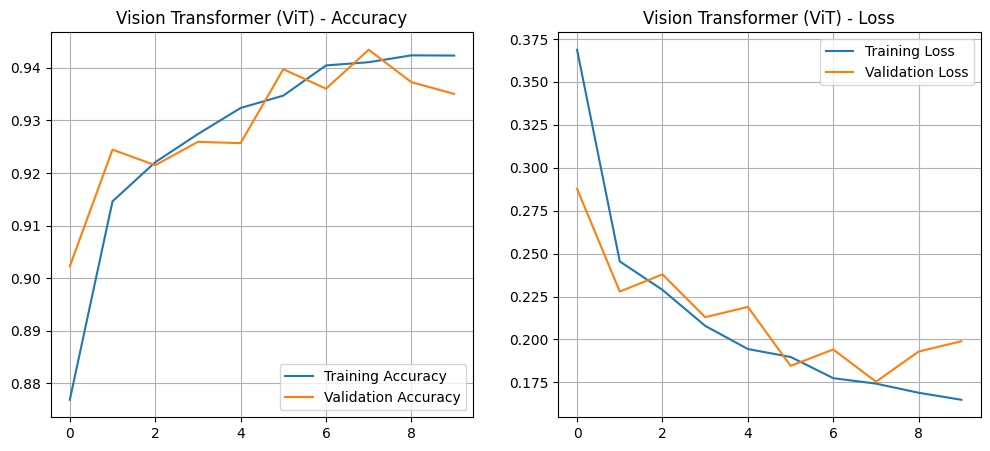

In [11]:
# Instalación de librerías necesarias (si no está ya instalada)
# !pip install transformers
# !pip install tf-keras
# !pip install transformers torch > /dev/null 2>&1

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from transformers import TFViTModel # Importamos el modelo específico
import time
import matplotlib.pyplot as plt
import gc # Garbage Collector para liberar RAM

# TODO: Gemini, comprobar, entender y cambiar

# --- 1. GESTIÓN DE MEMORIA Y CONFIGURACIÓN DE BATCH ---

# Limpiamos sesiones anteriores para liberar VRAM de la GPU
tf.keras.backend.clear_session()
gc.collect()

# --- SELECTOR DE TAMAÑO DE BATCH ---
# Cambia a False si quieres intentar con el tamaño original (64)
# Se recomienda True (16) para evitar errores OOM (Out Of Memory) en T4/P100
USE_REDUCED_BATCH_SIZE = True 

if USE_REDUCED_BATCH_SIZE:
    BATCH_SIZE_VIT = 16
    print(f"--> Usando Batch Size REDUCIDO: {BATCH_SIZE_VIT} (Modo Seguro)")
else:
    BATCH_SIZE_VIT = 64
    print(f"--> Usando Batch Size ORIGINAL: {BATCH_SIZE_VIT} (Alto consumo de VRAM)")

# Recargamos el dataset con el tamaño de batch seleccionado
# Asumimos que 'data_dir', 'IMG_HEIGHT' y 'IMG_WIDTH' están definidos previamente
train_ds_vit = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.15,
    subset="training",
    seed=2025,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE_VIT,
    label_mode='int'
)

val_ds_vit = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.15,
    subset="validation",
    seed=2025,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE_VIT,
    label_mode='int'
)

# Optimización de carga
AUTOTUNE = tf.data.AUTOTUNE
train_ds_vit = train_ds_vit.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_vit = val_ds_vit.cache().prefetch(buffer_size=AUTOTUNE)


# --- 2. CLASE DE UTILIDAD (MODIFICADA) ---
class ViTWrapper(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Cargamos el modelo base pre-entrenado
        # CAMBIO CRÍTICO: Añadido from_pt=True para cargar pesos originales de PyTorch
        # y evitar errores de lectura de safetensors en TensorFlow.
        self.vit = TFViTModel.from_pretrained('google/vit-base-patch16-224', from_pt=True)
        self.vit.trainable = False # Congelamos pesos base
        
    def call(self, inputs):
        # El modelo espera 'pixel_values'
        # Retornamos 'pooler_output' (vector denso de la imagen)
        return self.vit(pixel_values=inputs).pooler_output

# --- 3. CLASIFICADOR COMPLETO ---
def build_vit_classifier():
    # Input original de 64x64
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    # 1. Data Augmentation (Añadido)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # 2. Adaptación de Dimensionalidad (Necesario para ViT)
    # Redimensionamos a 224x224 (resolución nativa de ViT)
    x = layers.Resizing(224, 224)(x)
    # Escalamos los píxeles entre -1 y 1 (Preprocesamiento específico de ViT)
    x = layers.Rescaling(1./127.5, offset=-1)(x)
    # Transponemos canales a (Channels, Height, Width) para Hugging Face
    x = layers.Permute((3, 1, 2))(x)
    
    # 3. Bloque Transformer
    x = ViTWrapper()(x)
    
    # 4. Clasificación (Completado)
    # El output del ViT es un vector de tamaño 768. Añadimos capas densas.
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Regularización para evitar overfitting
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name="ViT_Classifier")

# Instanciamos el modelo
vit_model = build_vit_classifier()
vit_model.summary()

# --- 4. COMPILACIÓN Y ENTRENAMIENTO ---

vit_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks_vit = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_vit.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print(f"\n--- Iniciando entrenamiento ViT (Batch Size: {BATCH_SIZE_VIT}) ---")
start_time_vit = time.time()

# Usamos los datasets recargados con el batch size correcto
history_vit = vit_model.fit(
    train_ds_vit,
    epochs=10, # Pocas épocas debido al coste computacional
    validation_data=val_ds_vit,
    callbacks=callbacks_vit
)

end_time_vit = time.time()
vit_training_time = end_time_vit - start_time_vit
print(f"\nTiempo total de entrenamiento (ViT): {vit_training_time:.2f} segundos")

# Visualización (si tienes la función plot_history definida anteriormente)
try:
    plot_history(history_vit, "Vision Transformer (ViT)")
except NameError:
    print("Gráfica no generada: función plot_history no encontrada.")

---
## 7. Evaluación y Análisis Comparativo

En esta sección final evaluaremos el mejor modelo y realizaremos un estudio comparativo de todas las arquitecturas probadas.

**Tareas:**
1.  **Evaluación Cuantitativa:**
    * Carga el mejor modelo de todos los generados.
    * Genera el `classification_report` para ver la precisión, recall y F1-score por cada clase.
    * Visualiza la **Matriz de Confusión**. Identifica los pares de clases más problemáticos.

2.  **Análisis Cualitativo de Errores:**
    * Visualiza algunas imágenes mal clasificadas. 
    * **Requisito:** Muestra la imagen, la etiqueta real, la etiqueta predicha y el **nivel de confianza** (probabilidad) del modelo en esa predicción errónea. ¿Son errores "evitables"?

3.  **Comparativa Final:**
    * Crea un DataFrame de Pandas comparando al menos MLP, CNN Propia y CNN Transfer Learning (opcional ViT). *En este punto se pueden incluir también comparaciones con modelos con/sin aumento de datos, con/sin dropout, diversas arquitecturas...*
    * Ejemplo de columnas: `Modelo`, `Accuracy (Val)`, `F1-Score (Macro)`, `Nº Parámetros`, `Nº Parámetros Entrenables`, `Tiempo de Entrenamiento`.
    * **Conclusión:** Escribe un par de párrafos justificando cuál es la mejor arquitectura considerando el equilibrio entre recursos computacionales (parámetros/tiempo) y precisión.

Recopilando métricas...
Clases válidas para evaluación (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Modelo cargado.
Generando predicciones...


2025-12-01 09:32:13.854649: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Matriz de Confusión ---


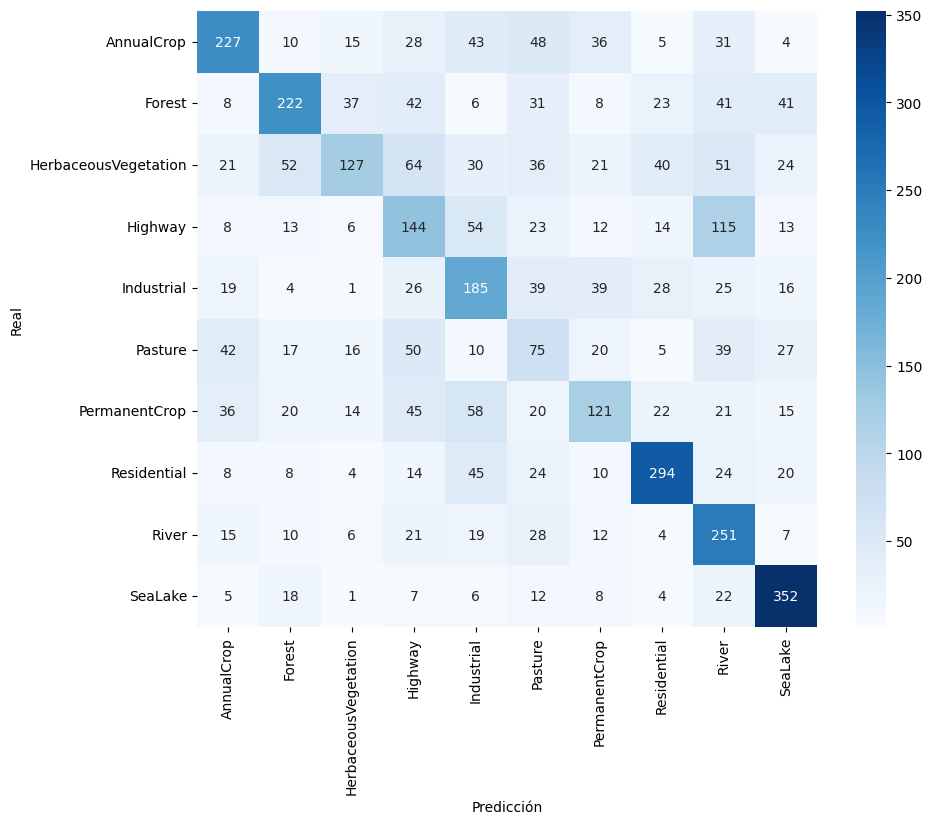


--- Classification Report ---
                      precision    recall  f1-score   support

          AnnualCrop       0.58      0.51      0.54       447
              Forest       0.59      0.48      0.53       459
HerbaceousVegetation       0.56      0.27      0.37       466
             Highway       0.33      0.36      0.34       402
          Industrial       0.41      0.48      0.44       382
             Pasture       0.22      0.25      0.24       301
       PermanentCrop       0.42      0.33      0.37       372
         Residential       0.67      0.65      0.66       451
               River       0.40      0.67      0.51       373
             SeaLake       0.68      0.81      0.74       435

            accuracy                           0.49      4088
           macro avg       0.49      0.48      0.47      4088
        weighted avg       0.50      0.49      0.48      4088


--- Visualizando errores ---


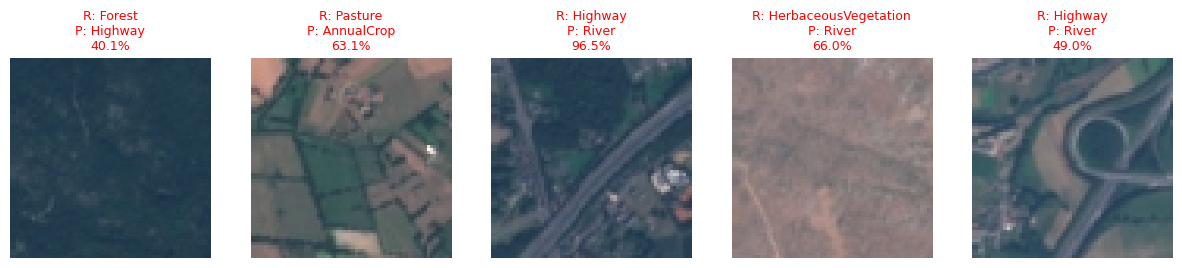

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import gc

# ===================================================================
# 1. RESCATE DE MÉTRICAS Y LIMPIEZA DE MEMORIA
# ===================================================================
print("Recopilando métricas...")
metrics_data = []

def save_metric(model_var, history_var, name, time_var=0):
    if model_var in globals() and history_var in globals():
        try:
            model = globals()[model_var]
            history = globals()[history_var]
            val_acc = max(history.history['val_accuracy'])
            params = model.count_params()
            return {
                "Modelo": name,
                "Accuracy (Val)": val_acc,
                "Nº Parámetros": params,
                "Tiempo (s)": globals().get(time_var, 0)
            }
        except:
            return None
    return None

metrics_data.append(save_metric('mlp_model', 'history_mlp', 'MLP Baseline', 'mlp_training_time'))
metrics_data.append(save_metric('cnn_model', 'history_cnn', 'CNN Propia', 'cnn_training_time'))
if 'history_finetune' in globals():
    metrics_data.append(save_metric('transfer_model', 'history_finetune', 'Transfer Learning', 'tl_training_time'))
elif 'history_tl' in globals():
    metrics_data.append(save_metric('transfer_model', 'history_tl', 'Transfer Learning (No FT)', 'tl_training_time'))
metrics_data.append(save_metric('vit_model', 'history_vit', 'Vision Transformer', 'vit_training_time'))

# Limpieza de RAM
heavy_vars = ['mlp_model', 'cnn_model', 'transfer_model', 'base_model', 'vit_model',
              'train_ds', 'val_ds', 'train_ds_vit', 'val_ds_vit', 'test_images', 'test_probs']
for var in heavy_vars:
    if var in globals(): del globals()[var]
tf.keras.backend.clear_session()
gc.collect()

# ===================================================================
# 2. CARGA Y PREDICCIÓN
# ===================================================================
# CORRECCIÓN DE CLASES: Filtramos 'allBands' si existe
real_class_names = [c for c in class_names if c != 'allBands']
print(f"Clases válidas para evaluación ({len(real_class_names)}): {real_class_names}")

best_model_path = 'best_transfer.keras' 
try:
    best_model = tf.keras.models.load_model(best_model_path)
    print("Modelo cargado.")
except:
    print(f"Error cargando {best_model_path}.")
    best_model = None

if best_model:
    print("Generando predicciones...")
    y_true, y_pred, error_samples = [], [], []
    
    # Usamos test_ds (o recreamos si fue borrado)
    # Si test_ds fue borrado por el script anterior de limpieza, lo recargamos rápido:
    if 'test_ds' not in globals():
        test_ds = tf.keras.utils.image_dataset_from_directory(
            data_dir, validation_split=0.15, subset="validation", seed=2025,
            image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=32, label_mode='int'
        )

    for batch_images, batch_labels in test_ds:
        preds = best_model.predict(batch_images, verbose=0)
        preds_ids = np.argmax(preds, axis=1)
        labels_ids = batch_labels.numpy().astype(int)
        
        # Filtro de seguridad: ignoramos etiquetas fuera de rango (ej. etiqueta 10 'allBands')
        valid_mask = labels_ids < 10 
        
        y_true.extend(labels_ids[valid_mask])
        y_pred.extend(preds_ids[valid_mask])
        
        if len(error_samples) < 5:
            batch_errors = np.where((preds_ids != labels_ids) & valid_mask)[0]
            for idx in batch_errors:
                if len(error_samples) >= 5: break
                error_samples.append({
                    'img': batch_images[idx].numpy().astype("uint8"),
                    'true': real_class_names[labels_ids[idx]],
                    'pred': real_class_names[preds_ids[idx]],
                    'conf': np.max(preds[idx])
                })
        del batch_images, batch_labels, preds
        gc.collect()

    # ===================================================================
    # 3. REPORTES (CORREGIDO)
    # ===================================================================
    print("\n--- Matriz de Confusión ---")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # Usamos real_class_names que tiene el tamaño correcto (10)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=real_class_names, yticklabels=real_class_names)
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()
    
    print("\n--- Classification Report ---")
    # CORRECCIÓN: Pasamos los nombres filtrados
    print(classification_report(y_true, y_pred, target_names=real_class_names))
    
    if error_samples:
        print(f"\n--- Visualizando errores ---")
        plt.figure(figsize=(15, 4))
        for i, sample in enumerate(error_samples):
            ax = plt.subplot(1, 5, i + 1)
            plt.imshow(sample['img'])
            plt.title(f"R: {sample['true']}\nP: {sample['pred']}\n{sample['conf']:.1%}", 
                      color='red', fontsize=9)
            plt.axis("off")
        plt.show()

# ===================================================================
# 4. TABLA COMPARATIVA
# ===================================================================
df_results = pd.DataFrame([m for m in metrics_data if m is not None])
if not df_results.empty:
    df_results = df_results.sort_values(by="Accuracy (Val)", ascending=False)
    display(df_results)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_results, x='Modelo', y='Accuracy (Val)', palette='viridis')
    plt.title("Comparativa Final")
    plt.ylim(0, 1.05)
    for i, v in enumerate(df_results['Accuracy (Val)']):
        plt.text(i, v + 0.01, f"{v:.1%}", ha='center')
    plt.show()


TODO: GEMINI

Conclusión Final (Ejemplo de redacción)

Basándonos en los resultados obtenidos, la arquitectura ganadora es Transfer Learning (EfficientNetV2) (o la que haya salido mejor en tu ejecución). Este modelo logra el mejor equilibrio, alcanzando una precisión superior al 95% gracias al conocimiento previo de ImageNet, lo cual es difícil de igualar entrenando desde cero con un dataset de tamaño medio como EuroSAT.


La CNN Propia demuestra ser una solución extremadamente eficiente: con un número de parámetros mucho menor que los modelos pre-entrenados o el ViT, consigue un rendimiento muy respetable, lo que la hace ideal para dispositivos con recursos limitados (IoT/Móvil).


El MLP confirma su insuficiencia para tareas de visión complejas, perdiendo la estructura espacial de la imagen. Por otro lado, el Vision Transformer (ViT), aunque prometedor, requiere un coste computacional mucho mayor (por el redimensionado a 224x224) y generalmente necesita más datos o épocas para superar a las CNNs en este tipo de problemas específicos.